In [1]:
import pickle
from matplotlib import pyplot as plt
from matplotlib import colors
import numpy as np

In [2]:
def plot_3d(axs, filename, maxdb, maxdg, maxp):
    with open(f'/lustre/scratch127/qpg/jc59/new_qubo_formulation/oriented/param_exploration/LR_unequal.{filename}.db{maxdb}.dg{maxdg}.p{maxp}.pkl', 'rb') as f:
        res = pickle.load(f)
    energies = res['energies']
    delta_bs = res['delta_bs']
    delta_gs = res['delta_gs']
    ps = res['ps']
    energies = np.array(energies)
    print(np.min(np.min(energies, axis=1), axis=1))

    norm = colors.Normalize(vmin=0, vmax=np.max(energies))
    plot_ps = [int(np.floor(x)) for x in np.linspace(0, len(ps)-1, len(axs))] 
    
    print(
        [
            (
                round(delta_bs[np.unravel_index(np.argmin(energies[plot_ps[i],:,:]), energies[plot_ps[i],:,:].shape)[0]],2), 
                round(delta_gs[np.unravel_index(np.argmin(energies[plot_ps[i],:,:]), energies[plot_ps[i],:,:].shape)[1]],2)
            ) 
            for i in range(len(axs)) 
        ]
    ) 
    
      
    for i in range(len(axs)):
        ax = axs[i]
        im = ax.pcolormesh(np.log10(delta_bs), np.log10(delta_gs), energies[plot_ps[i],:,:].T, shading='nearest', norm=norm)
        ix, iy = np.unravel_index(np.argmin(energies[plot_ps[i],:,:]), energies[plot_ps[i],:,:].shape)
        x_max = np.log10(delta_bs)[ix]
        y_max = np.log10(delta_gs)[iy]
        ax.plot(
            x_max, y_max,
            marker='x',
            color='red',
            markersize=8,
            # markeredgecolor='white',
            zorder=10
        )
        ax.set_xlabel(r'$\log(\Delta_\beta)$')
        ax.set_ylabel(r'$\log(\Delta_\gamma)$')
        ax.set_title(ps[plot_ps[i]])
        cbar = ax.figure.colorbar(im, ax=ax)
        label = r'$H_C$'
        cbar.ax.set_ylabel(label, rotation=0, va="bottom", labelpad=10)
    return axs

[1.90125e+01 9.26950e+00 4.79925e+00 1.64300e+00 2.02750e-01 1.62500e-02]
[(np.float64(0.79), np.float64(0.1)), (np.float64(0.5), np.float64(0.1)), (np.float64(0.5), np.float64(0.13)), (np.float64(0.5), np.float64(0.16)), (np.float64(0.32), np.float64(0.1)), (np.float64(0.25), np.float64(0.1))]
[9.605800e+01 2.662325e+01 1.260525e+01 5.016750e+00 1.235000e+00
 1.850000e-02]
[(np.float64(2.51), np.float64(0.1)), (np.float64(0.5), np.float64(0.1)), (np.float64(0.5), np.float64(0.1)), (np.float64(0.4), np.float64(0.16)), (np.float64(0.79), np.float64(0.13)), (np.float64(0.79), np.float64(0.13))]


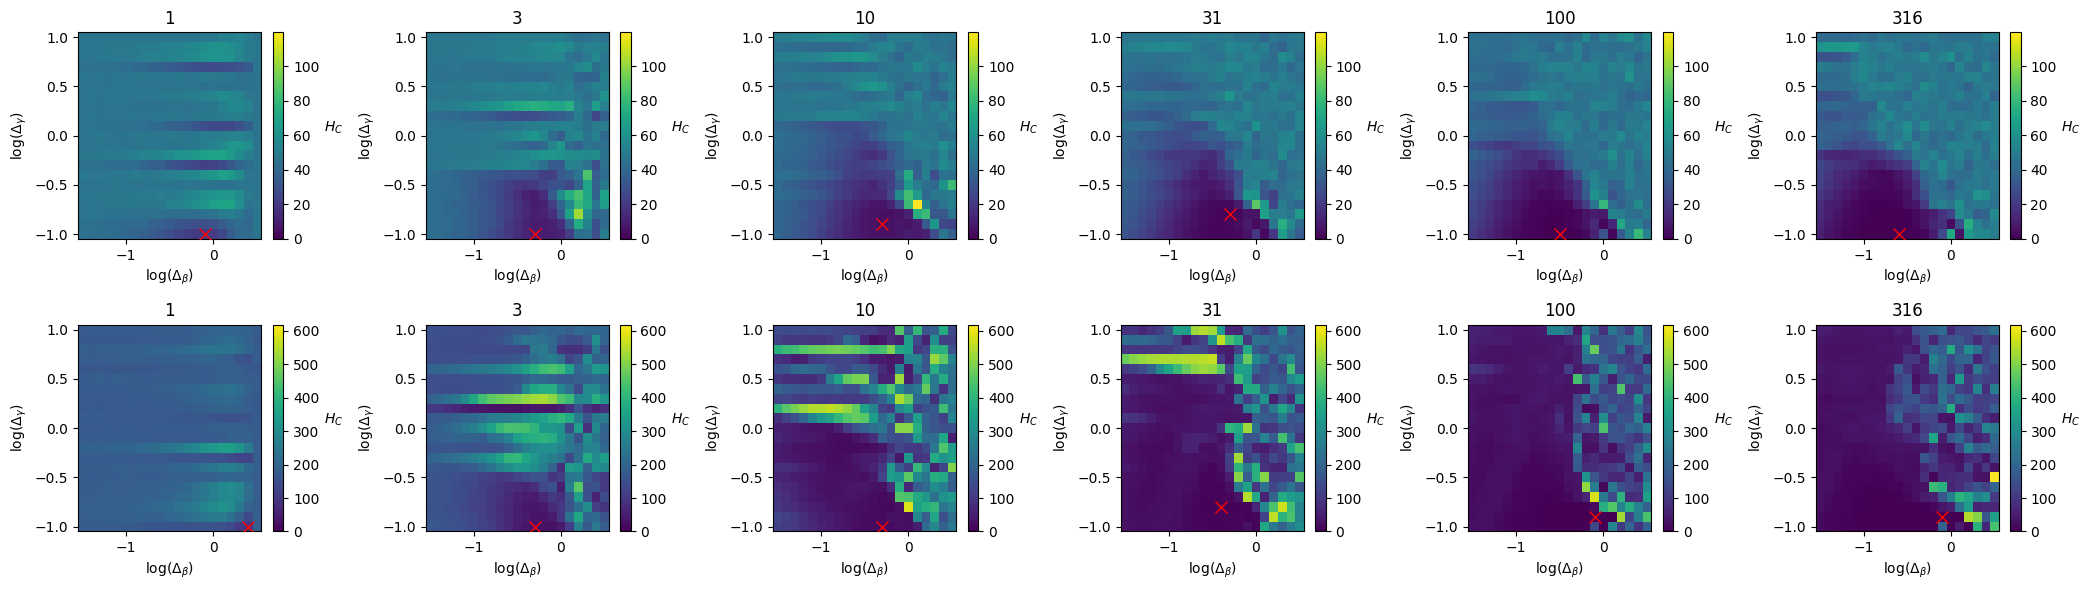

In [4]:
fig, axs = plt.subplots(2, 6)
db = 3.16
dg = 10.0
maxp = 316
plot_3d(axs[0, :], 'test_N2_W2', db, dg, maxp)
plot_3d(axs[1, :], 'trivial', db, dg, maxp)
# plot_p_opt_3d(axs[2, :], 'test_N7_W2', db, dg, maxp)
# plot_p_opt_3d(axs[3, :], 'test_N8_W3', db, dg, maxp)



fig.set_figheight(3 * len(axs[:,0]))
fig.set_figwidth(3.5 * len(axs[0,:]))
plt.tight_layout()

In [12]:
def plot_p_opt_3d(axs, filename, maxdb, maxdg, maxp, qubits):
    with open(f'/lustre/scratch127/qpg/jc59/new_qubo_formulation/oriented/param_exploration/LR_unequal.{filename}.db{maxdb}.dg{maxdg}.p{maxp}.pkl', 'rb') as f:
        res = pickle.load(f)
    p_opts = res['p_opts']
    delta_bs = res['delta_bs']
    delta_gs = res['delta_gs']
    ps = res['ps']
    p_opts = np.array(p_opts)
    print(np.max(np.max(p_opts, axis=1), axis=1))

    # norm = colors.Normalize(vmin=0, vmax=np.log10(np.max(p_opts)))
    plot_ps = [int(np.floor(x)) for x in np.linspace(0, len(ps)-1, len(axs))] 
    cmap = plt.get_cmap()
    cmap.set_over('yellow')
    cmap.set_under('black')

    
    print(
        [
            (
                round(delta_bs[np.unravel_index(np.argmax(p_opts[plot_ps[i],:,:]), p_opts[plot_ps[i],:,:].shape)[0]],2), 
                round(delta_gs[np.unravel_index(np.argmax(p_opts[plot_ps[i],:,:]), p_opts[plot_ps[i],:,:].shape)[1]],2)
            ) 
            for i in range(len(axs)) 
        ]
    ) 
    
      
    for i in range(len(axs)):
        ax = axs[i]
        im = ax.pcolormesh(np.log10(delta_bs), np.log10(delta_gs), qubits + np.log2(p_opts[plot_ps[i],:,:].T), shading='nearest', cmap=cmap, vmin=0)
        ix, iy = np.unravel_index(np.argmax(p_opts[plot_ps[i],:,:]), p_opts[plot_ps[i],:,:].shape)
        x_max = np.log10(delta_bs)[ix]
        y_max = np.log10(delta_gs)[iy]
        ax.plot(
            x_max, y_max,
            marker='x',
            color='red',
            markersize=8,
            # markeredgecolor='white',
            zorder=10
        )
        ax.set_xlabel(r'$\log(\Delta_\beta)$')
        ax.set_ylabel(r'$\log(\Delta_\gamma)$')
        ax.set_title(ps[plot_ps[i]])
        cbar = ax.figure.colorbar(im, ax=ax)
        label = r'$p_{\text{opt}}$'
        cbar.ax.set_ylabel(label, rotation=0, va="bottom", labelpad=10)
    return axs

[0.1395  0.1905  0.442   0.83275 0.98125 0.9985 ]
[(np.float64(1.26), np.float64(1.26)), (np.float64(0.63), np.float64(0.2)), (np.float64(0.79), np.float64(0.16)), (np.float64(0.5), np.float64(0.2)), (np.float64(0.4), np.float64(0.1)), (np.float64(0.25), np.float64(0.1))]


/tmp/ipykernel_2167959/2604079228.py:31: RuntimeWarning: divide by zero encountered in log2
  im = ax.pcolormesh(np.log10(delta_bs), np.log10(delta_gs), qubits + np.log2(p_opts[plot_ps[i],:,:].T), shading='nearest', cmap=cmap, vmin=0)


[0.002   0.01525 0.131   0.4135  0.79625 0.99725]
[(np.float64(1.26), np.float64(0.5)), (np.float64(0.5), np.float64(0.13)), (np.float64(0.63), np.float64(0.2)), (np.float64(0.79), np.float64(0.16)), (np.float64(0.4), np.float64(0.16)), (np.float64(1.0), np.float64(0.13))]


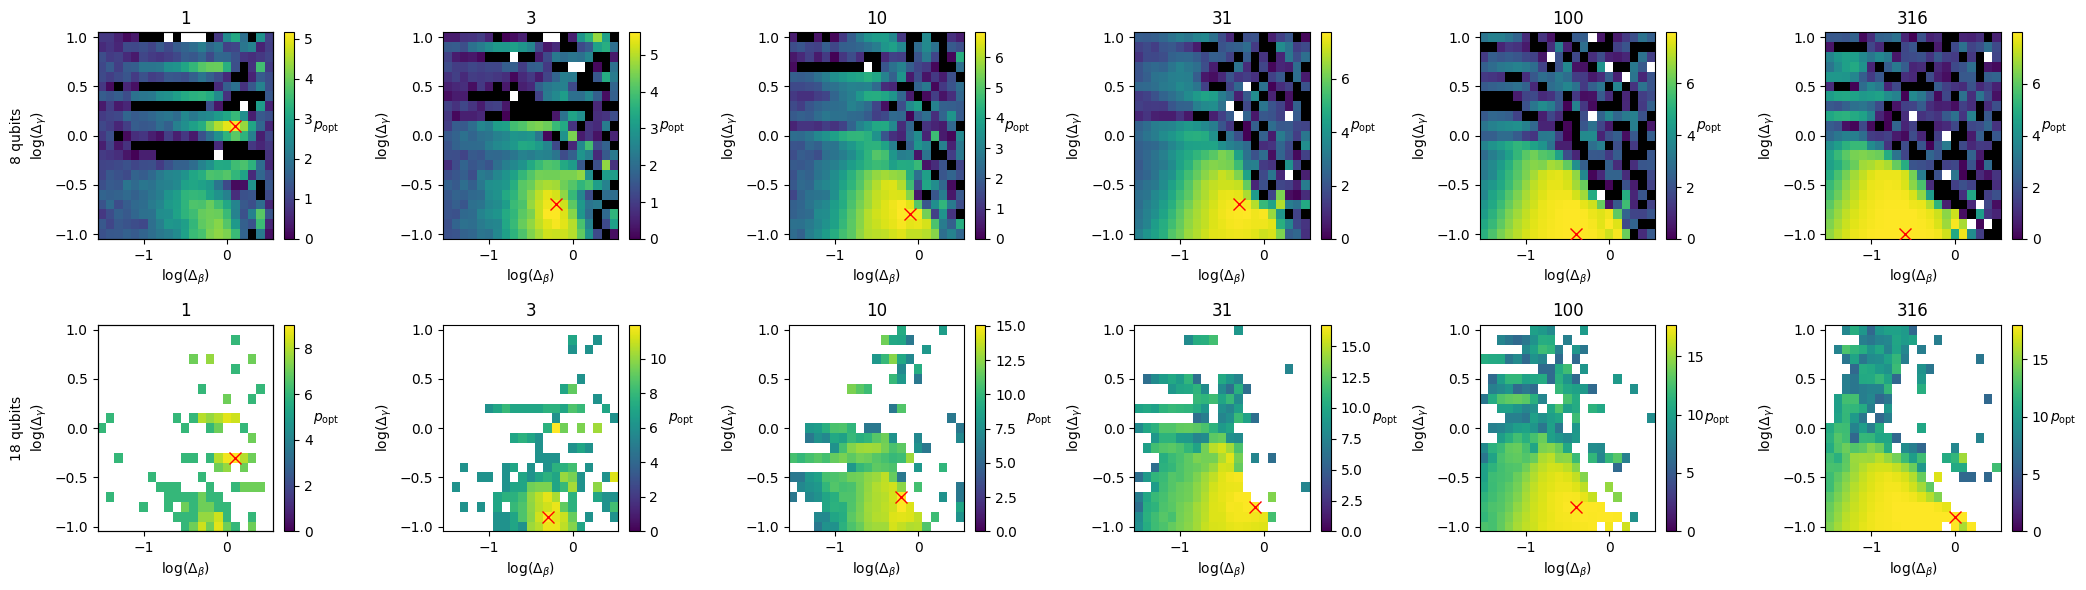

In [13]:
fig, axs = plt.subplots(2, 6)
db = 3.16
dg = 10.0
maxp = 316
qubits = [8, 18]
plot_p_opt_3d(axs[0, :], 'test_N2_W2', db, dg, maxp, qubits[0])
plot_p_opt_3d(axs[1, :], 'trivial', db, dg, maxp, qubits[1])
# plot_p_opt_3d(axs[2, :], 'test_N3_W4', db, dg, maxp)
# plot_p_opt_3d(axs[3, :], 'test_N8_W3', db, dg, maxp)
qubits = [8, 18]
for idx, ax in enumerate(axs[:, 0]):
    twin = ax.twinx()
    twin.set_yticks([])
    twin.set_ylabel(f'{qubits[idx]} qubits')
    twin.yaxis.set_label_coords(-0.5,0.5)


fig.set_figheight(3 * len(axs[:,0]))
fig.set_figwidth(3.5 * len(axs[0,:]))
plt.tight_layout()

In [18]:
2**18

262144

In [27]:
128000 / (2**18)

0.48828125

In [25]:
np.log2(4000 / (2**8))

np.float64(3.965784284662087)

In [15]:
filename = 'trivial'
maxdb = 3.16
maxdg = 10.0
maxp = 316
with open(f'/lustre/scratch127/qpg/jc59/new_qubo_formulation/oriented/param_exploration/LR_unequal.{filename}.db{maxdb}.dg{maxdg}.p{maxp}.pkl', 'rb') as f:
    res = pickle.load(f)
p_opts = res['p_opts']
delta_bs = res['delta_bs']
delta_gs = res['delta_gs']
ps = res['ps']
p_opts = np.array(p_opts)

In [22]:
np.unravel_index(np.argmax(p_opts[2,:,:]), p_opts[2,:,:].shape)

(np.int64(13), np.int64(3))

In [23]:
p_opts[2,:,:][13, 3]

np.float64(0.131)

In [24]:
p_opts[2,:,:][14, 3]

np.float64(0.0)

In [42]:
filename = 'test_N2_W2'
data_file = f'/lustre/scratch127/qpg/jc59/new_qubo_formulation/oriented/qubo_data/qubo_data_{filename}.gfa.pkl'
from qiskit_qaoa.utils.hamiltonian_utils import get_normalised_Q_and_hamiltonian

_, hamiltonian, _, ising_offset, _, ham_norm = get_normalised_Q_and_hamiltonian(data_file)
hamiltonian = hamiltonian * ham_norm
ising_offset = ising_offset * ham_norm
num_qubits: int = hamiltonian.num_qubits

In [36]:
num_qubits

8

In [ ]:
from hubo_qaoa.utils.str_utils import genbin
from qiskit_qaoa.utils.string_utils import evaluate_sparse_pauli_samples

keys = list(genbin(num_qubits))
evals = (evaluate_sparse_pauli_samples(keys, hamiltonian) + ising_offset)
opt_evals = np.nonzero(evals < 1e-5)
print(f'Opt evals: {opt_evals}')

NameError: name 'num_qubits' is not defined

In [18]:
len(evals)

256

In [21]:
2 ** -7

0.0078125

In [29]:
evals[40], evals[65]

(np.float64(-9.769962616701378e-15), np.float64(9.769962616701378e-15))

In [98]:
from qiskit_aer import AerSimulator
from qiskit.quantum_info import SparsePauliOp
from qiskit_aer.primitives import SamplerV2 as Sampler

backend = AerSimulator()
sampler = Sampler.from_backend(backend)
shots = 100

hamiltonian = SparsePauliOp(['IIII', 'ZZII'], [1,1])

def get_energy_and_p_opt(qc):
    job = sampler.run([qc], shots=shots)
    sampler_result = job.result()
    counts = sampler_result[0].data.meas.get_counts()
    print(counts)
    evals = evaluate_sparse_pauli_samples(counts.keys(), hamiltonian)
    samples, energies = [], []
    for idx, (sample, count) in enumerate(counts.items()):
        samples.extend(count * [sample])
        energies.extend(count * [evals[idx]])
    energies = np.array(energies)
    energy = np.mean(energies)
    p_opt = np.flatnonzero(energies < 1e-5).shape[0] / shots
    return energy, p_opt

In [99]:
evaluate_sparse_pauli_samples(['0000', '1100', '1000'], hamiltonian)

array([2., 2., 0.])

In [100]:
from qiskit import QuantumCircuit

qc = QuantumCircuit(4)
qc.rx(np.pi/4, 2)
qc.h(3)
qc.measure_all()
get_energy_and_p_opt(qc)

{'1000': 35, '0000': 44, '0100': 9, '1100': 12}


(np.float64(1.12), 0.44)

In [101]:
from qiskit.circuit.library import QAOAAnsatz
from qiskit import transpile

qc = QAOAAnsatz(hamiltonian,flatten=True)
qc.assign_parameters([np.pi*3/4, np.pi/4], inplace=True)
qc.measure_all()
get_energy_and_p_opt(qc)

{'0011': 6, '0001': 8, '1101': 6, '1011': 3, '1110': 8, '0000': 4, '1001': 7, '0101': 7, '1100': 6, '0110': 4, '0010': 11, '0100': 8, '1010': 7, '1111': 5, '0111': 8, '1000': 2}


(np.float64(1.08), 0.46)

In [28]:
from qubo_qaoa.utils.str_utils import genbin

In [37]:
keys = list(genbin(8))
keys

['00000000',
 '00000001',
 '00000010',
 '00000011',
 '00000100',
 '00000101',
 '00000110',
 '00000111',
 '00001000',
 '00001001',
 '00001010',
 '00001011',
 '00001100',
 '00001101',
 '00001110',
 '00001111',
 '00010000',
 '00010001',
 '00010010',
 '00010011',
 '00010100',
 '00010101',
 '00010110',
 '00010111',
 '00011000',
 '00011001',
 '00011010',
 '00011011',
 '00011100',
 '00011101',
 '00011110',
 '00011111',
 '00100000',
 '00100001',
 '00100010',
 '00100011',
 '00100100',
 '00100101',
 '00100110',
 '00100111',
 '00101000',
 '00101001',
 '00101010',
 '00101011',
 '00101100',
 '00101101',
 '00101110',
 '00101111',
 '00110000',
 '00110001',
 '00110010',
 '00110011',
 '00110100',
 '00110101',
 '00110110',
 '00110111',
 '00111000',
 '00111001',
 '00111010',
 '00111011',
 '00111100',
 '00111101',
 '00111110',
 '00111111',
 '01000000',
 '01000001',
 '01000010',
 '01000011',
 '01000100',
 '01000101',
 '01000110',
 '01000111',
 '01001000',
 '01001001',
 '01001010',
 '01001011',
 '01001100',

In [ ]:
evals = evaluate_sparse_pauli_samples(keys, hamiltonian) + ising_offset
evals

array([ 27.,  16.,  16.,  27.,  16.,  25.,  25.,  56.,  16.,  25.,  25.,
        56.,  27.,  56.,  56., 107.,  16.,   7.,   7.,  20.,   5.,  16.,
        16.,  49.,   5.,  16.,  16.,  49.,  16.,  47.,  47., 100.,  16.,
         7.,   7.,  20.,   5.,  16.,  16.,  49.,   0.,  11.,  11.,  44.,
        11.,  42.,  42.,  95.,  27.,  20.,  20.,  35.,  16.,  29.,  29.,
        64.,  11.,  24.,  24.,  59.,  22.,  55.,  55., 110.,  16.,   0.,
         5.,  11.,   7.,  11.,  16.,  42.,   7.,  11.,  16.,  42.,  20.,
        44.,  49.,  95.,  25.,  11.,  16.,  24.,  16.,  22.,  27.,  55.,
        16.,  22.,  27.,  55.,  29.,  55.,  60., 108.,  25.,  11.,  16.,
        24.,  16.,  22.,  27.,  55.,  11.,  17.,  22.,  50.,  24.,  50.,
        55., 103.,  56.,  44.,  49.,  59.,  47.,  55.,  60.,  90.,  42.,
        50.,  55.,  85.,  55.,  83.,  88., 138.,  16.,   5.,   5.,  16.,
         7.,  16.,  16.,  47.,   7.,  16.,  16.,  47.,  20.,  49.,  49.,
       100.,  25.,  16.,  16.,  29.,  16.,  27.,  2

u0+ 0001
u0- 0010
u1+ 0100
u1- 1000
"Read time and nodes right to left" ie. "Reverse and read left to right"

In [45]:
int('00000001', 2)

1

In [ ]:
evals[int('00101000', 2)]

np.float64(0.0)

In [60]:
evals[int('01000001', 2)]

np.float64(0.0)